<a href="https://colab.research.google.com/github/Prekshabarjatya/linear-regression-python/blob/main/Notebooks/predictions_and_model_objects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictions and Model Objects in Linear Regression

In this notebook, I explore how to:
- Use regression models to make predictions  
- Work with model objects in statsmodels  
- Understand regression to the mean  
- Transform variables to improve modeling  
- Perform back-transformations for interpretation  

## Objectives
- Make predictions using a fitted OLS model  
- Extract and use model parameters  
- Understand limitations of predictions  
- Apply transformations to variables  

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

In [3]:
np.random.seed(42)

real_estate_data = pd.DataFrame({
    "n_convenience": np.random.randint(0, 11, 100),
    "price_twd_msq": 5 + 0.8 * np.random.randint(0, 11, 100) + np.random.normal(0, 1, 100)
})

In [4]:
model = ols("price_twd_msq ~ n_convenience", data=real_estate_data).fit()
print(model.params)

Intercept        8.620332
n_convenience    0.114912
dtype: float64


## Making predictions
We use the fitted model to predict house prices for new values of explanatory variables.

In [5]:
new_data = pd.DataFrame({"n_convenience": [0, 5, 10]})

predictions = model.predict(new_data)
print(predictions)

0    8.620332
1    9.194891
2    9.769451
dtype: float64


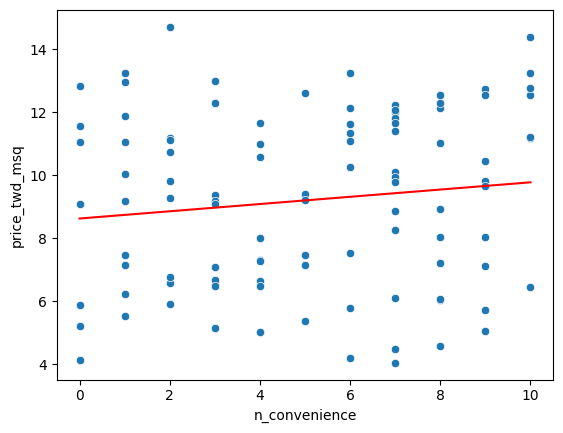

In [6]:
sns.scatterplot(x="n_convenience", y="price_twd_msq", data=taiwan_real_estate)
sns.lineplot(x=new_data["n_convenience"], y=predictions, color="red")

plt.show()

## Limits of Prediction
- Model only works well within observed data range  
- Extrapolation can lead to unreliable results

In [7]:
print(model.summary())
print(model.params)
print(model.rsquared)
print(model.pvalues)

                            OLS Regression Results                            
Dep. Variable:          price_twd_msq   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.582
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.211
Time:                        04:52:51   Log-Likelihood:                -243.62
No. Observations:                 100   AIC:                             491.2
Df Residuals:                      98   BIC:                             496.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         8.6203      0.542     15.915

In [8]:
intercept = model.params[0]
slope = model.params[1]

manual_prediction = intercept + slope * 5
print(manual_prediction)

9.194891286527266


/tmp/ipykernel_887/1756352293.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = model.params[0]
/tmp/ipykernel_887/1756352293.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = model.params[1]


## Regression to the Mean
Extreme values tend to move closer to the average in repeated measurements.


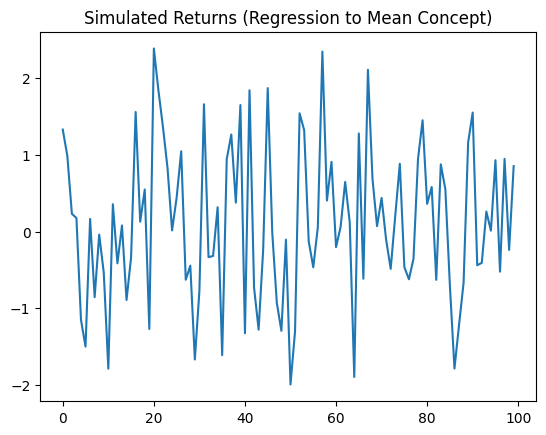

In [9]:
returns = np.random.normal(0, 1, 100)

sns.lineplot(data=returns)
plt.title("Simulated Returns (Regression to Mean Concept)")
plt.show()

## Transforming Variables
We can improve model performance by transforming variables (log, sqrt, etc.)

In [14]:
real_estate_data["log_convenience"] = np.log1p(real_estate_data["n_convenience"])
model_log = ols("price_twd_msq ~ log_convenience", data=real_estate_data).fit()
print(model_log.params)

Intercept          8.579283
log_convenience    0.385093
dtype: float64


In [15]:
real_estate_data["log_price"] = np.log1p(real_estate_data["price_twd_msq"])

model_log2 = ols("log_price ~ n_convenience", data=real_estate_data).fit()
print(model_log2.params)

Intercept        2.224485
n_convenience    0.011243
dtype: float64


In [16]:
pred_log = model_log2.predict(taiwan_real_estate)

pred_original = np.expm1(pred_log)
print(pred_original.head())

0    8.894125
1    8.565981
2    9.349227
3    9.005989
4    8.674135
dtype: float64


## Conclusion
- Linear regression models can be used for prediction  
- Model objects store useful statistical information  
- Transformations help improve model fit and interpretation  
- Predictions must be interpreted carefully, especially outside data range  